In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gp
import pickle
import arviz as az
import os
import sys
import matplotlib.colors as mcolors

In [3]:
cd ../

In [4]:
sys.path.insert(0, './src/')

In [5]:
from plot.odds_ratios import *

In [6]:
idata_mrp = az.from_netcdf('./idata/uk/rsv_intent_ord_soc.nc')
with open('./dat/dat_for_inference/uk/var_mappings_mrp_ord.p', 'rb') as f:
    var_mappings_mrp = pickle.load(f)
with open('./dat/dat_for_inference/uk/data_dict_mrp_ord.p', 'rb') as f:
    data_dict_mrp = pickle.load(f)
survey_mrp = pd.read_csv('./dat/dat_for_inference/uk/survey_mrp_ord.tsv', sep = '\t', index_col = 0)
micro_mrp = pd.read_csv('./dat/dat_for_inference/uk/micro_mrp_ord.tsv', sep = '\t', index_col = 0)

itl3_to_country = dict( zip(micro_mrp['itl3'], micro_mrp['country'] )  )

survey_mrp['country'] = survey_mrp['itl3'].map(itl3_to_country)

In [7]:
lad21_to_itl21 = pd.read_csv('./dat/region_mappings/Local_Authority_District_(April_2021)_to_LAU1_to_ITL3_to_ITL2_to_ITL1_(January_2021)_Lookup_in_United_Kingdom.csv')
itl321_cd_to_nm = dict( zip (lad21_to_itl21['ITL321CD'], lad21_to_itl21['ITL321NM']) )
itl221_cd_to_nm = dict( zip (lad21_to_itl21['ITL221CD'], lad21_to_itl21['ITL221NM']) )
itl121_cd_to_nm = dict( zip (lad21_to_itl21['ITL121CD'], lad21_to_itl21['ITL121NM']) )

In [8]:
itl321_cd_to_itl221_cd = dict( zip (lad21_to_itl21['ITL321CD'], lad21_to_itl21['ITL221CD']) )
itl321_cd_to_itl121_cd = dict( zip (lad21_to_itl21['ITL321CD'], lad21_to_itl21['ITL121CD']) )
itl321_cd_to_itl221_cd['TLM61_64_65_66'] = 'TLM6'
itl321_cd_to_itl121_cd['TLM61_64_65_66'] = 'TLM'

micro_mrp['itl2'] = micro_mrp['itl3'].map(itl321_cd_to_itl221_cd)
micro_mrp['itl1'] = micro_mrp['itl3'].map(itl321_cd_to_itl121_cd)

survey_mrp['itl2'] = survey_mrp['itl3'].map(itl321_cd_to_itl221_cd)
survey_mrp['itl1'] = survey_mrp['itl3'].map(itl321_cd_to_itl121_cd)

micro_mrp['Marginal'] = 'marginal'
survey_mrp['Marginal'] = 'marginal'

In [9]:
recode_mapping_reverse = var_mappings_mrp['recode_mapping_reverse']

rename_mapping_for_plot = {}

recode_mapping_for_plot = recode_mapping_reverse.copy()

value_mapping = {}

value_mapping['DIS'] = {
    'Not disabled under the Equality Act': 'Not disabled',
    
    'Disabled under the Equality Act: Day-to-day activities limited a little': 'Disabled:\nlimited a little',
    
    'Disabled under the Equality Act: Day-to-day activities limited a lot': 'Disabled:\nlimited a lot'
}

value_mapping['EMP'] = {
    'Economically inactive: Student': 'Student, inactive',
    'Economically Active Full-time students': 'Student, active',
    'Economically inactive: Long-term sick or disabled': 'Long-term sick',
    'Economically inactive: Other': 'Inactive other',
    'Economically inactive: Looking after home or family': 'Looking after home',
    'Working part or full-time (including self-employed, excluding students)': 'Working',
    'Economically active (excluding full-time students): Unemployed: Seeking work or waiting to start a job already obtained: Available to start working within 2 weeks': 'Seeking work',
    'Economically inactive: Retired': 'Retired'
}

value_mapping['LAN'] = {'English (English or Welsh in Wales)' : 'English', 'Other' : 'Other', 'Polish' : 'Polish'}

for _var, _mapping in value_mapping.items():
    new_dict = recode_mapping_for_plot[_var].copy()
    new_dict = { k : _mapping[v] for k,v in new_dict.items() }
    recode_mapping_for_plot[_var] = new_dict.copy()

for k in recode_mapping_for_plot:
    rename_mapping_for_plot[k] = { v : recode_mapping_for_plot[k][i] for i,v in recode_mapping_reverse[k].items()}

rename_mapping_for_plot['itl3'] = itl321_cd_to_nm

rename_mapping_for_plot['itl2'] = itl221_cd_to_nm

rename_mapping_for_plot['itl1'] = itl121_cd_to_nm

rename_mapping_for_plot['itl3']['TLM61_64_65_66'] = 'TLM61-64-65-66'

rename_mapping_for_plot['country'] = {'ew' :'England Wales', 'ni' : 'Northern Ireland', 'scot' : 'Scotland'}

rename_mapping_for_plot['Marginal'] = {'marginal' : 'Marginal'}

recode_mapping_for_plot['Marginal'] = {0 : 'Marginal'}

for k,d in rename_mapping_for_plot.items():
    if k in survey_mrp.columns:
        survey_mrp[k] = survey_mrp[k].map(d)

soc_dems = ['AGE', 'SEX', 'EDU', 'REL', 'ETH', 'LAN', 'MIG', 'BUK', 'YUK', 'HEA', 'SCH', 'DIS', 'ENP', 'EMP']

In [10]:
alpha_violin_plot_soc = 0.7
alpha_soc_backgound = 0.45

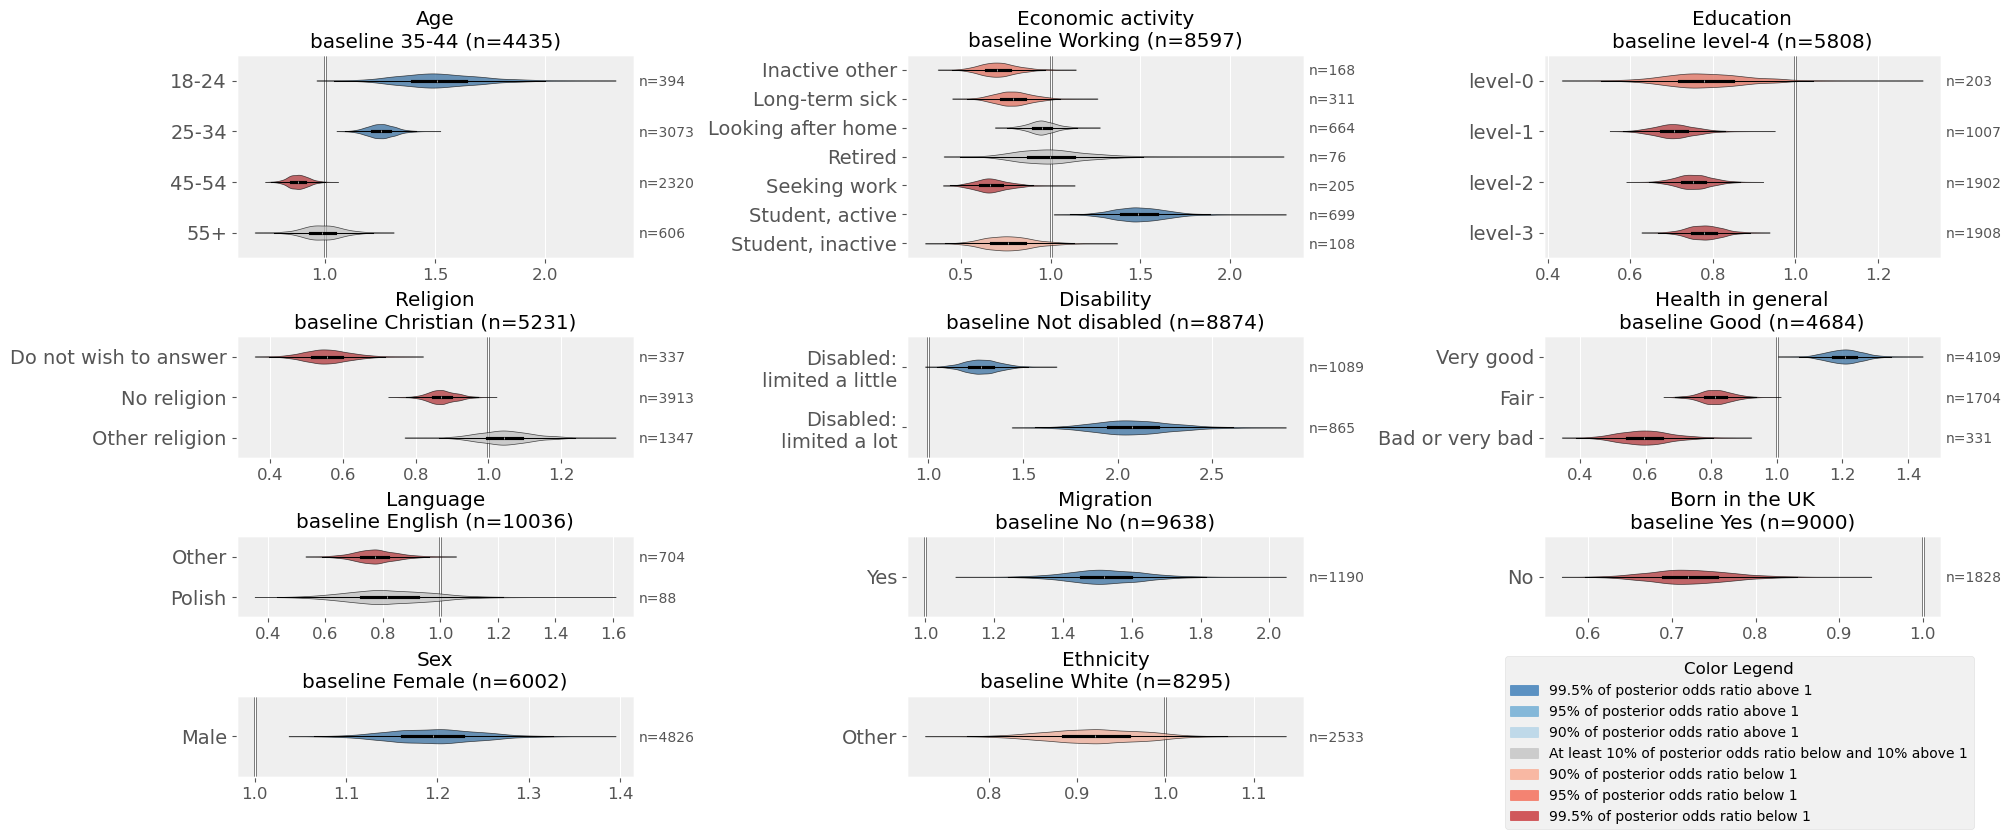

In [11]:
title_var_names = {'AGE': 'Age',
 'SEX': 'Sex',
 'EDU': 'Education',
 'REL': 'Religion',
 'ETH': 'Ethnicity',
 'LAN': 'Language',
 'HHLAN': 'Household language English',
 'MIG': 'Migration',
 'BUK': 'Born in the UK',
 'YUK': 'Year of arrival in UK',
 'HEA': 'Health in general',#'Fair',
 'SCH': 'No',
 'DIS': 'Disability',
 'ENP': 'Enlgish proficieny',
 'EMP': 'Economic activity',}

baselines = {'AGE': '35-44', # '18-24',
 'SEX': 'Female',
 'EDU': 'level-4',
 'REL': 'Christian',
 'ETH': 'White',
 'LAN': 'English',
 'MIG': 'No',
 'BUK': 'Yes',
 'ENP': 'Very well or well',
 'DIS' : 'Not disabled',
 'HEA': 'Good', #'Fair',
 'EMP': 'Working',
 'SCH': 'No',
}


plt.style.use('ggplot')

orderd_labels_dict = {}
for var_name in ['ETH','REL','LAN','EMP','EDU','AGE']:
    orderd_labels_dict[var_name] = list( np.sort( list( recode_mapping_for_plot[var_name].values() ) ) )

orderd_labels_dict['HEA'] = ['Very good', 'Good', 'Fair', 'Bad or very bad']
orderd_labels_dict['DIS'] = ['Not disabled', 'Disabled:\nlimited a little', 'Disabled:\nlimited a lot']

height_ratios = [5, 3, 2, 2]

fig, axes = plt.subplots(4,3, figsize = (20,8), constrained_layout = True, height_ratios = height_ratios )
for k, (var_name, coef_name) in enumerate( zip(['AGE','EMP', 'EDU','REL','DIS','HEA','LAN','MIG','BUK','SEX','ETH'], #, 'SCH'],
                                              ['beta_age', 'beta_emp', 'beta_edu', 'beta_rel', 'beta_dis', 'beta_hea', 'beta_lan', 'beta_mig', 'beta_buk', 'beta_sex', 'beta_eth']) #, 'beta_sch'])
                                         ):
    i,j = k //3, k%3
    ax = axes[i,j]
    h_ratio = height_ratios[i]
    num_violin_plots = len(recode_mapping_reverse[var_name].values()) - 1
    _title = f'{title_var_names[var_name]}\nbaseline {baselines[var_name]}'
    plot_odds_ratio(idata = idata_mrp, ax = ax, recode_mapping_reverse = recode_mapping_for_plot, coef_name = coef_name, var_name = var_name, title =_title, num_samples = 2000, 
                    plot_type = 'violin', violin_width = 0.35*(num_violin_plots/h_ratio), max_len_label = 30, baseline = baselines[var_name], survey = survey_mrp, add_n = True,#  palette = palette,
                    alpha = alpha_violin_plot_soc, orderd_labels_dict = orderd_labels_dict )
    ax.tick_params(axis='y', labelsize=14)
    ax.tick_params(axis='x', labelsize=12)

    ax.patch.set_facecolor( mcolors.to_rgba('gainsboro', alpha_soc_backgound) )
    
axes[3,2].remove()
add_custom_legend(fig, anchor_x = 5/6 + 1/30, anchor_y = -0.05, framealpha = 0.5, fontsize=10, title_fontsize=12, #  palette = palette,
                  alpha = alpha_violin_plot_soc )

fig.savefig('./fig/uk/rsv_intent_mrp_uk_odds_ratio.jpg', dpi = 200, bbox_inches='tight')

In [12]:
import geopandas as gpd
import matplotlib.pyplot as plt

# from https://open-geography-portalx-ons.hub.arcgis.com/api/download/v1/items/f602e96224994ee5b37d3131cd60803b/shapefile?layers=0
itl3_map = gpd.read_file('./dat/geo_boundaries/International_Territorial_Level_3_January_2021_UK_BGC_V3_2022_8770952818551609998/ITL3_JAN_2021_UK_BGC_V3.shp')
# itl3_map.set_index('ITL321CD', inplace = True)
itl3_map = itl3_map.astype({'LAT': np.float64, 'LONG' : np.float64})

# from https://ckan.publishing.service.gov.uk/dataset/
itl2_map = gpd.read_file('./dat/geo_boundaries/International_Territorial_Level_2_January_2021_UK_BUC_V2_2022_4451431189849328963//ITL2_JAN_2021_UK_BUC_V2.shp')
# itl3_map.set_index('ITL321CD', inplace = True)
itl2_map = itl2_map.astype({'LAT': np.float64, 'LONG' : np.float64})

# from https://ckan.publishing.service.gov.uk/dataset/
itl1_map = gpd.read_file('./dat/geo_boundaries/International_Territorial_Level_1_January_2021_UK_BGC_2022_-1020202586535011846//ITL1_MAY_2021_UK_BGC.shp')
# itl3_map.set_index('ITL321CD', inplace = True)
itl1_map = itl1_map.astype({'LAT': np.float64, 'LONG' : np.float64})

# itl1_map.set_index('ITL121CD', inplace = True)
# itl2_map.set_index('ITL221CD', inplace = True)
# itl3_map.set_index('ITL321CD', inplace = True)

# itl3_weights = micro_mrp[['itl3','n']].copy()

In [13]:

# List of ITL3 regions to combine
regions_to_combine = ['TLM61', 'TLM64', 'TLM65', 'TLM66']

subset = itl3_map[itl3_map['ITL321CD'].isin(regions_to_combine)]

combined_geometry = subset.dissolve()  # No need to specify column, as we want one result

new_region = gpd.GeoDataFrame({
    'ITL321CD': ['TLM61-64-65-66'],  # New name for the combined region
    'BNG_E': [subset['BNG_E'].mean()],  # Optional: average other attributes like centroid coordinates
    'BNG_N': [subset['BNG_N'].mean()],
    'LONG': [subset['LONG'].mean()],
    'LAT': [subset['LAT'].mean()],
    'GlobalID': [None],  # You can modify this depending on your needs
    'geometry': combined_geometry['geometry']
})

itl3_map_updated = itl3_map[~itl3_map['ITL321CD'].isin(regions_to_combine)]  # Remove original regions

itl3_map_updated = gpd.GeoDataFrame(pd.concat([itl3_map_updated, new_region], ignore_index=True))

itl3_map_updated.loc[itl3_map_updated['ITL321CD'] == 'TLM61-64-65-66', 'ITL321NM'] = 'TLM61-64-65-66'

itl3_map_updated = itl3_map_updated.set_index('ITL321NM')

itl2_map = itl2_map.set_index('ITL221NM')
itl1_map = itl1_map.set_index('ITL121NM')

In [14]:
df_post_strat_dict = {}
post_strat_path = './post_strat/uk'
_var_list =  ['AGE', 'SEX', 'EDU','REL', 'ETH', 'LAN', 'MIG', 'BUK', 'DIS', 'HEA', 'EMP', 'itl1', 'itl2', 'itl3', 'country', 'Marginal']
for var_post_strat in _var_list:
    for var_name in ['p','p1','p2','p3','p4']:
        _df = pd.read_csv( os.path.join(post_strat_path, f'{var_post_strat}_post_strat_rsv_intent_{var_name}.tsv'), sep = '\t', index_col = 0 )
        old_columns = _df.columns
        new_columns = [ f'{var_name}_{c}' for c in old_columns] # if c != var_post_strat]
        # print(new_columns)
        _df.columns = new_columns
        if var_name == 'p':
            df_post_strat_dict[ var_post_strat ] = _df.copy()
        else:
            df_post_strat_dict[ var_post_strat ] = pd.concat( [df_post_strat_dict[ var_post_strat ].copy(), _df.copy() ], axis = 1)
for var_post_strat in _var_list:
    if var_post_strat in rename_mapping_for_plot:
        _df = df_post_strat_dict[ var_post_strat ].copy()
        _df = _df.reset_index()
        _df[var_post_strat] = _df[ var_post_strat].map(rename_mapping_for_plot[var_post_strat])
        _df = _df.set_index(var_post_strat)
        _df = _df.sort_index(ascending=True)
        df_post_strat_dict[ var_post_strat ] = _df.copy()

In [15]:
itl3_pred = df_post_strat_dict['itl3'][['p_mean', 'p1_mean', 'p2_mean', 'p3_mean', 'p4_mean']]
itl3_map_updated[['p','p1','p2','p3','p4']] = itl3_pred

itl2_pred = df_post_strat_dict['itl2'][['p_mean', 'p1_mean', 'p2_mean', 'p3_mean', 'p4_mean']]
itl2_map[['p','p1','p2','p3','p4']] = itl2_pred

itl1_pred = df_post_strat_dict['itl1'][['p_mean', 'p1_mean', 'p2_mean', 'p3_mean', 'p4_mean']]
itl1_map[['p','p1','p2','p3','p4']] = itl1_pred

In [16]:
_var_list = ['AGE', 'SEX', 'EDU','REL', 'ETH', 'LAN', 'MIG', 'BUK', 'DIS', 'HEA', 'EMP'] #,'country'] # ,'EMP'
_var_list = ['Marginal'] + list(np.sort(_var_list)) + ['itl1']

category_labels = [
    'Unsure, but leaning toward Yes, or Yes definitey', 
    'No, definitely not', 
    'Unsure, but leaning towards no', 
    'Unsure, but leaning towards yes', 
    'Yes, definitely'
]
metrics = ['2.5 per.', 'median', '97.5 per.', 'mean']

def create_multiindex_columns(columns):
    new_columns = []
    for col in columns:
        if col.startswith('p'):
            # Separate "p" (base category) from specific category number if present
            category_num = col[1] if col[1].isdigit() else '0'  # '0' to represent 'p'
            metric_name = col.split('_')[1]  # Get '2.5percentile', etc.     
            # Map category number to category label
            category = category_labels[int(category_num)]
            # Map metric name to formatted metric label
            if '2.5' in metric_name:
                metric = '2.5 per.'
            elif '97.5' in metric_name:
                metric = '97.5 per.'
            elif '50' in metric_name:
                metric = 'median'
            elif 'mean' in metric_name:
                metric = 'mean'
            # Add a tuple (category, metric) to the new columns list
            new_columns.append((category, metric))
    return pd.MultiIndex.from_tuples(new_columns)

# Combine DataFrames into a single one with multi-index for both rows and columns
soc_itl1_df = pd.DataFrame()
itl2_df = pd.DataFrame()
itl3_df = pd.DataFrame()
itl2_itl3_df = pd.DataFrame()

for variable, df in df_post_strat_dict.items():
    if variable in _var_list:
        _df = df.copy()
        _df.columns = create_multiindex_columns(_df.columns)
        _df.index = pd.MultiIndex.from_product([[variable], _df.index], names=['Variable', 'Category'])
        soc_itl1_df = pd.concat([soc_itl1_df, _df])
    if variable in ['itl3']:
        _df = df.copy()
        _df.columns = create_multiindex_columns(_df.columns)
        _df.index = pd.MultiIndex.from_product([[variable], _df.index], names=['Variable', 'Category'])
        itl3_df = pd.concat([itl3_df, _df])

    if variable in ['itl2']:
        _df = df.copy()
        _df.columns = create_multiindex_columns(_df.columns)
        _df.index = pd.MultiIndex.from_product([[variable], _df.index], names=['Variable', 'Category'])
        itl2_df = pd.concat([itl2_df, _df])
    if variable in ['itl2','itl3']:
        _df = df.copy()
        _df.columns = create_multiindex_columns(_df.columns)
        _df.index = pd.MultiIndex.from_product([[variable], _df.index], names=['Variable', 'Category'])
        itl2_itl3_df = pd.concat([itl2_itl3_df, _df])


In [17]:
# Convert to LaTeX table format
uk_poststratified_table = soc_itl1_df.to_latex(multicolumn=True, multirow=True, float_format="%.3f")
with open("./tables/uk_poststratified_soc_itl1.tex", "w") as file:
    file.write(uk_poststratified_table)

_itl2_itl3_df = itl2_itl3_df.drop(columns="Unsure, but leaning toward Yes, or Yes definitey", level=0)
_itl2_df = itl2_df.drop(columns="Unsure, but leaning toward Yes, or Yes definitey", level=0)
_itl3_df = itl3_df.drop(columns="Unsure, but leaning toward Yes, or Yes definitey", level=0)

_itl2_df.index = _itl2_df.index.map(lambda x: tuple(s.replace('&', r'\&') for s in x))
_itl3_df.index = _itl3_df.index.map(lambda x: tuple(s.replace('&', r'\&') for s in x))

uk_poststratified_itl2_itl3_table = _itl2_itl3_df.to_latex(multicolumn=True, multirow=True, float_format="%.3f")
uk_poststratified_itl2_table = _itl2_df.to_latex(multicolumn=True, multirow=True, float_format="%.3f")
uk_poststratified_itl3_table = _itl3_df.to_latex(multicolumn=True, multirow=True, float_format="%.3f")


with open("./tables/uk_poststratified_itl2_itl3.tex", "w") as file:
    file.write(uk_poststratified_itl2_itl3_table)


with open("./tables/uk_poststratified_itl2.tex", "w") as file:
    file.write(uk_poststratified_itl2_table)


with open("./tables/uk_poststratified_itl3.tex", "w") as file:
    file.write(uk_poststratified_itl3_table)

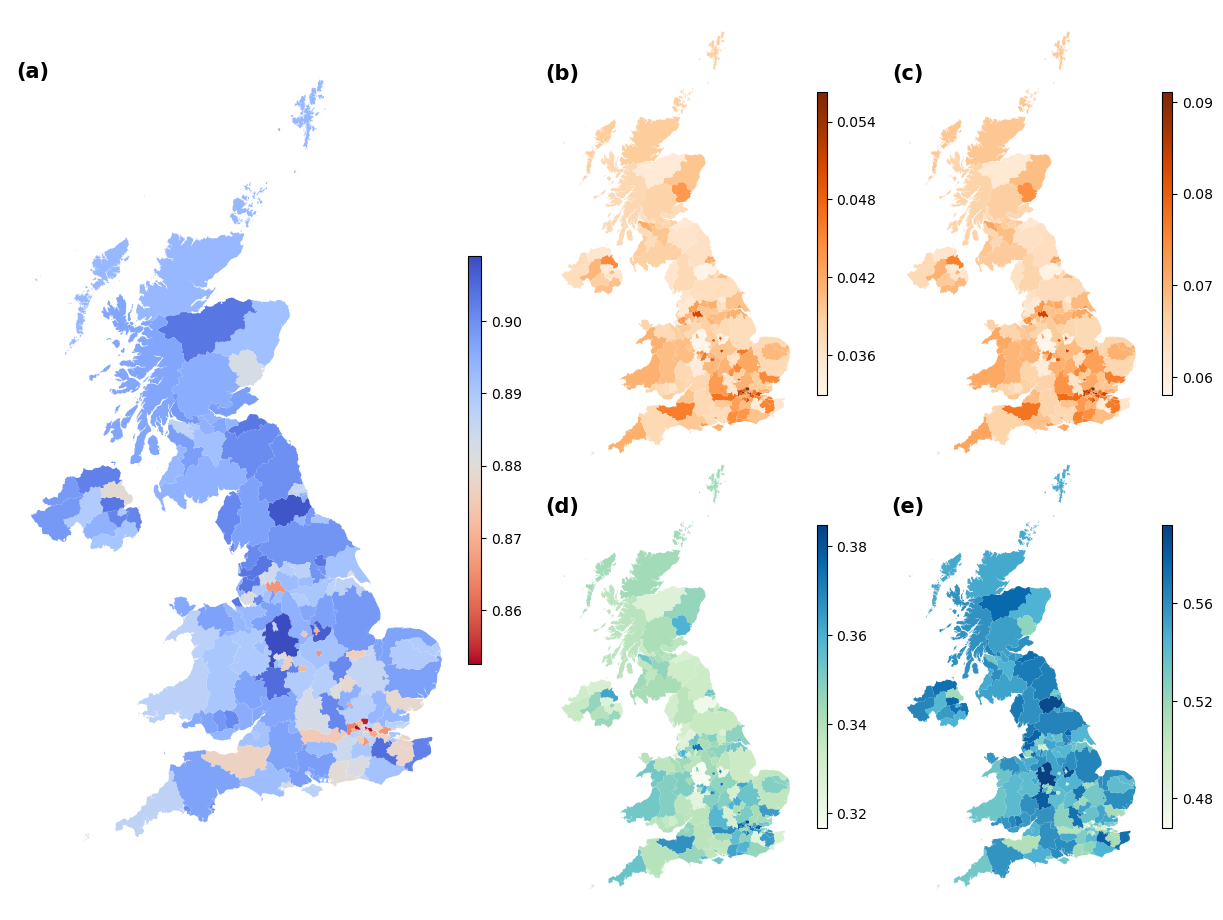

In [18]:
import matplotlib.ticker as ticker
from mpl_toolkits.axes_grid1 import make_axes_locatable

plt.style.use('default')

fig = plt.figure(figsize=(15, 15) ) 

gs = fig.add_gridspec(2, 3, width_ratios=[1.7, 1, 1], height_ratios=[1, 1]) # , wspace=0.5 )# , hspace=-1.5)

gs.update(wspace=0.2, hspace=-0.4)

ax1 = fig.add_subplot(gs[0, 1])
ax2 = fig.add_subplot(gs[0, 2])
ax3 = fig.add_subplot(gs[1, 1])
ax4 = fig.add_subplot(gs[1, 2])

ax0 = fig.add_subplot(gs[:, 0]) 

labels = ['(b)', '(c)', '(d)', '(e)']
for k, (ax, p, label, color_map) in enumerate(zip([ax1,ax2,ax3,ax4], ['p1', 'p2', 'p3', 'p4'], labels, ['Oranges','Oranges','GnBu', 'GnBu'])): # ['GnBu', 'GnBu', 'PuBu','PuBu'])):
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="4%", pad=0.15 )#0.15)
    itl3_map_updated.plot(column=p, legend=True, cmap= color_map, ax=ax, cax=cax)
    cbar = plt.colorbar(ax.collections[0], cax=cax)
    
    # Set a fixed aspect ratio for the colorbars
    cax.set_box_aspect(30)  
    cbar.locator = ticker.MaxNLocator(nbins=4) 
    cbar.update_ticks()
    ax.text(0.05, 0.85, label, transform=ax.transAxes, fontsize=15, fontweight='bold', ha='center')
    
    ax.set_axis_off()

label = '(a)'
ax = ax0
p = 'p'
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="3%", pad=0.05)
itl3_map_updated.plot(column=p, legend=True, cmap='coolwarm_r', ax=ax, cax=cax)
cbar = plt.colorbar(ax.collections[0], cax=cax)

# Set a fixed aspect ratio for the colorbars
cax.set_box_aspect(30)
cbar.locator = ticker.MaxNLocator(nbins=6) 
cbar.update_ticks()
ax.text(0.05, 0.955, label, transform=ax.transAxes, fontsize=15, fontweight='bold', ha='center')
ax.set_axis_off()

plt.subplots_adjust(hspace=-0.05)  

fig.savefig('./fig/uk/rsv_intent_uk_mrp_map.jpg', dpi = 200, bbox_inches='tight')

plt.show()

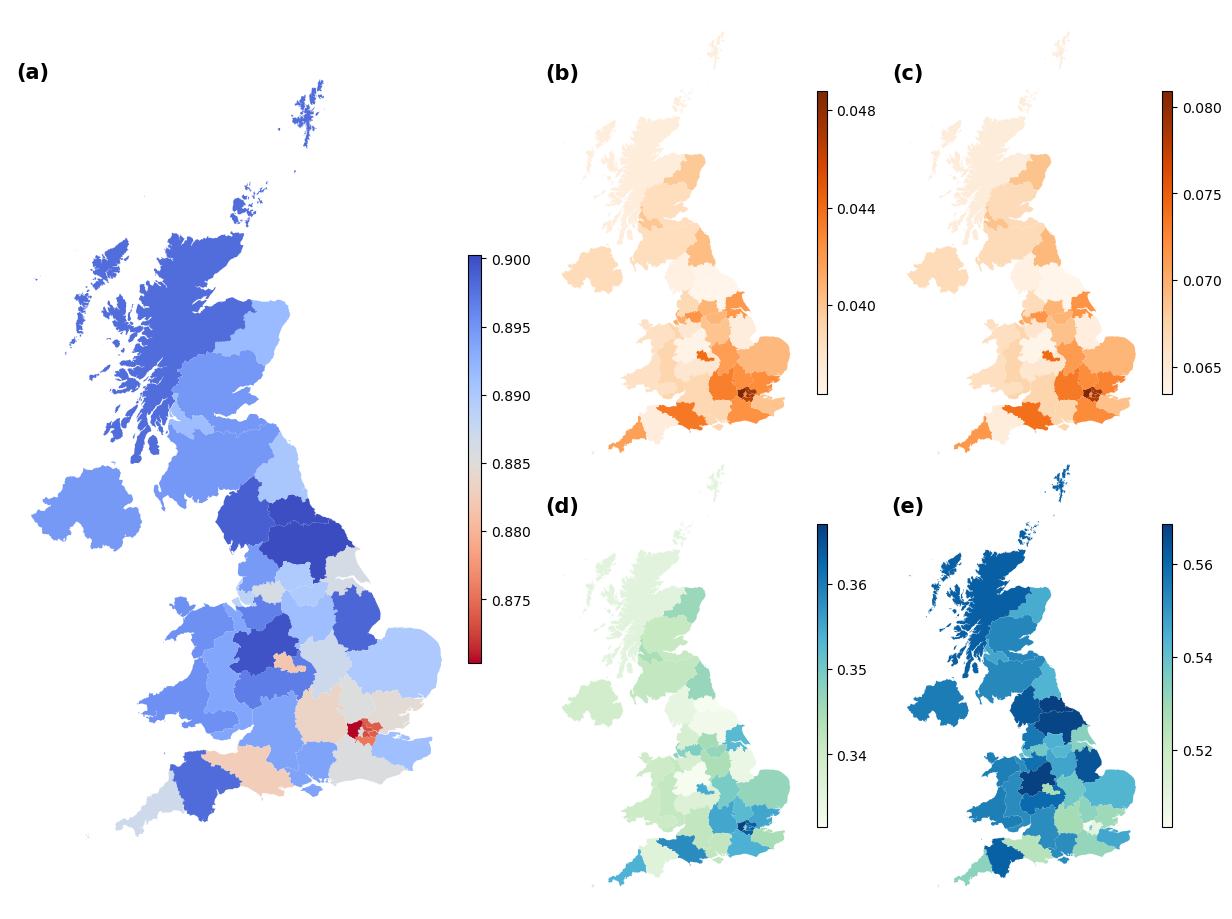

In [19]:
import matplotlib.ticker as ticker
from mpl_toolkits.axes_grid1 import make_axes_locatable

plt.style.use('default')

fig = plt.figure(figsize=(15, 15) )

gs = fig.add_gridspec(2, 3, width_ratios=[1.7, 1, 1], height_ratios=[1, 1]) # , wspace=0.5 )# , hspace=-1.5)

gs.update(wspace=0.2, hspace=-0.4)

ax1 = fig.add_subplot(gs[0, 1])
ax2 = fig.add_subplot(gs[0, 2])
ax3 = fig.add_subplot(gs[1, 1])
ax4 = fig.add_subplot(gs[1, 2])

ax0 = fig.add_subplot(gs[:, 0]) 

labels = ['(b)', '(c)', '(d)', '(e)']

for k, (ax, p, label, color_map) in enumerate(zip([ax1,ax2,ax3,ax4], ['p1', 'p2', 'p3', 'p4'], labels, ['Oranges','Oranges','GnBu', 'GnBu'])): # ['GnBu', 'GnBu', 'PuBu','PuBu'])):
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="4%", pad=0.15 )#0.15)
    itl2_map.plot(column=p, legend=True, cmap= color_map, ax=ax, cax=cax)
    cbar = plt.colorbar(ax.collections[0], cax=cax)
    
    # Set a fixed aspect ratio for the colorbars
    cax.set_box_aspect(30)
    cbar.locator = ticker.MaxNLocator(nbins=4) 
    cbar.update_ticks()
    ax.text(0.05, 0.85, label, transform=ax.transAxes, fontsize=15, fontweight='bold', ha='center')
    
    ax.set_axis_off()

label = '(a)'
ax = ax0
p = 'p'
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="3%", pad=0.05)
itl2_map.plot(column=p, legend=True, cmap='coolwarm_r', ax=ax, cax=cax)
cbar = plt.colorbar(ax.collections[0], cax=cax)

# Set a fixed aspect ratio for the colorbars
cax.set_box_aspect(30) 
cbar.locator = ticker.MaxNLocator(nbins=6) 
cbar.update_ticks()
ax.text(0.05, 0.955, label, transform=ax.transAxes, fontsize=15, fontweight='bold', ha='center')
ax.set_axis_off()

plt.subplots_adjust(hspace=-0.05)  

fig.savefig('./fig/uk/rsv_intent_uk_mrp_itl2map.jpg', dpi = 200, bbox_inches='tight')

plt.show()

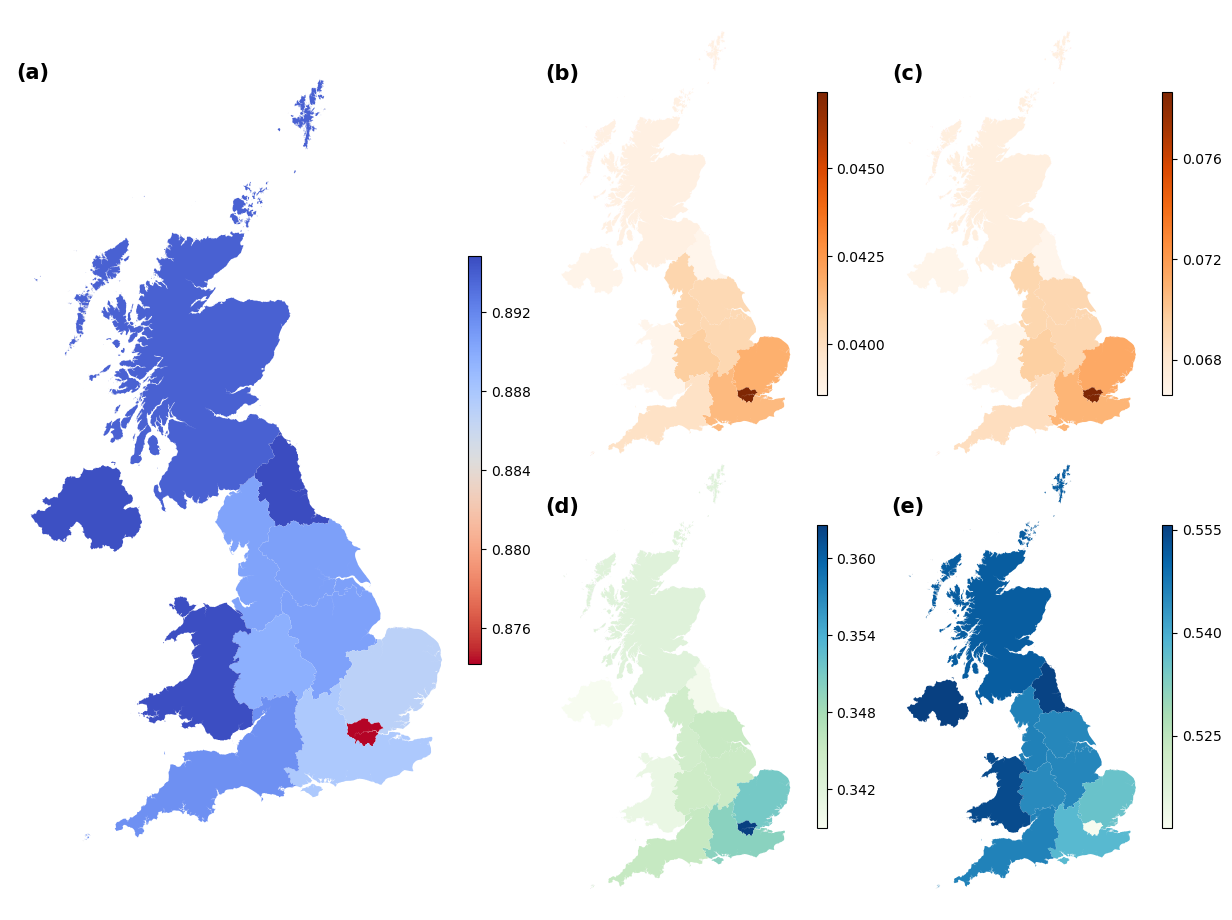

In [20]:
import matplotlib.ticker as ticker
from mpl_toolkits.axes_grid1 import make_axes_locatable

plt.style.use('default')

fig = plt.figure(figsize=(15, 15) ) # , constrained_layout=True)

gs = fig.add_gridspec(2, 3, width_ratios=[1.7, 1, 1], height_ratios=[1, 1]) # , wspace=0.5 )# , hspace=-1.5)

gs.update(wspace=0.2, hspace=-0.4)

ax1 = fig.add_subplot(gs[0, 1])
ax2 = fig.add_subplot(gs[0, 2])
ax3 = fig.add_subplot(gs[1, 1])
ax4 = fig.add_subplot(gs[1, 2])

ax0 = fig.add_subplot(gs[:, 0]) 

labels = ['(b)', '(c)', '(d)', '(e)']
for k, (ax, p, label, color_map) in enumerate(zip([ax1,ax2,ax3,ax4], ['p1', 'p2', 'p3', 'p4'], labels, ['Oranges','Oranges','GnBu', 'GnBu'])): # ['GnBu', 'GnBu', 'PuBu','PuBu'])):
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="4%", pad=0.15 )#0.15)
    itl1_map.plot(column=p, legend=True, cmap= color_map, ax=ax, cax=cax)
    cbar = plt.colorbar(ax.collections[0], cax=cax)
    
    # Set a fixed aspect ratio for the colorbars
    cax.set_box_aspect(30)
    cbar.locator = ticker.MaxNLocator(nbins=4) 
    cbar.update_ticks()
    ax.text(0.05, 0.85, label, transform=ax.transAxes, fontsize=15, fontweight='bold', ha='center')
    
    ax.set_axis_off()

label = '(a)'
ax = ax0
p = 'p'
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="3%", pad=0.05)
itl1_map.plot(column=p, legend=True, cmap='coolwarm_r', ax=ax, cax=cax)
cbar = plt.colorbar(ax.collections[0], cax=cax)

# Set a fixed aspect ratio for the colorbars
cax.set_box_aspect(30) 
cbar.locator = ticker.MaxNLocator(nbins=6) 
cbar.update_ticks()
ax.text(0.05, 0.955, label, transform=ax.transAxes, fontsize=15, fontweight='bold', ha='center')
ax.set_axis_off()

plt.subplots_adjust(hspace=-0.05)  

fig.savefig('./fig/uk/rsv_intent_uk_mrp_itl1map.jpg', dpi = 200, bbox_inches='tight')

plt.show()

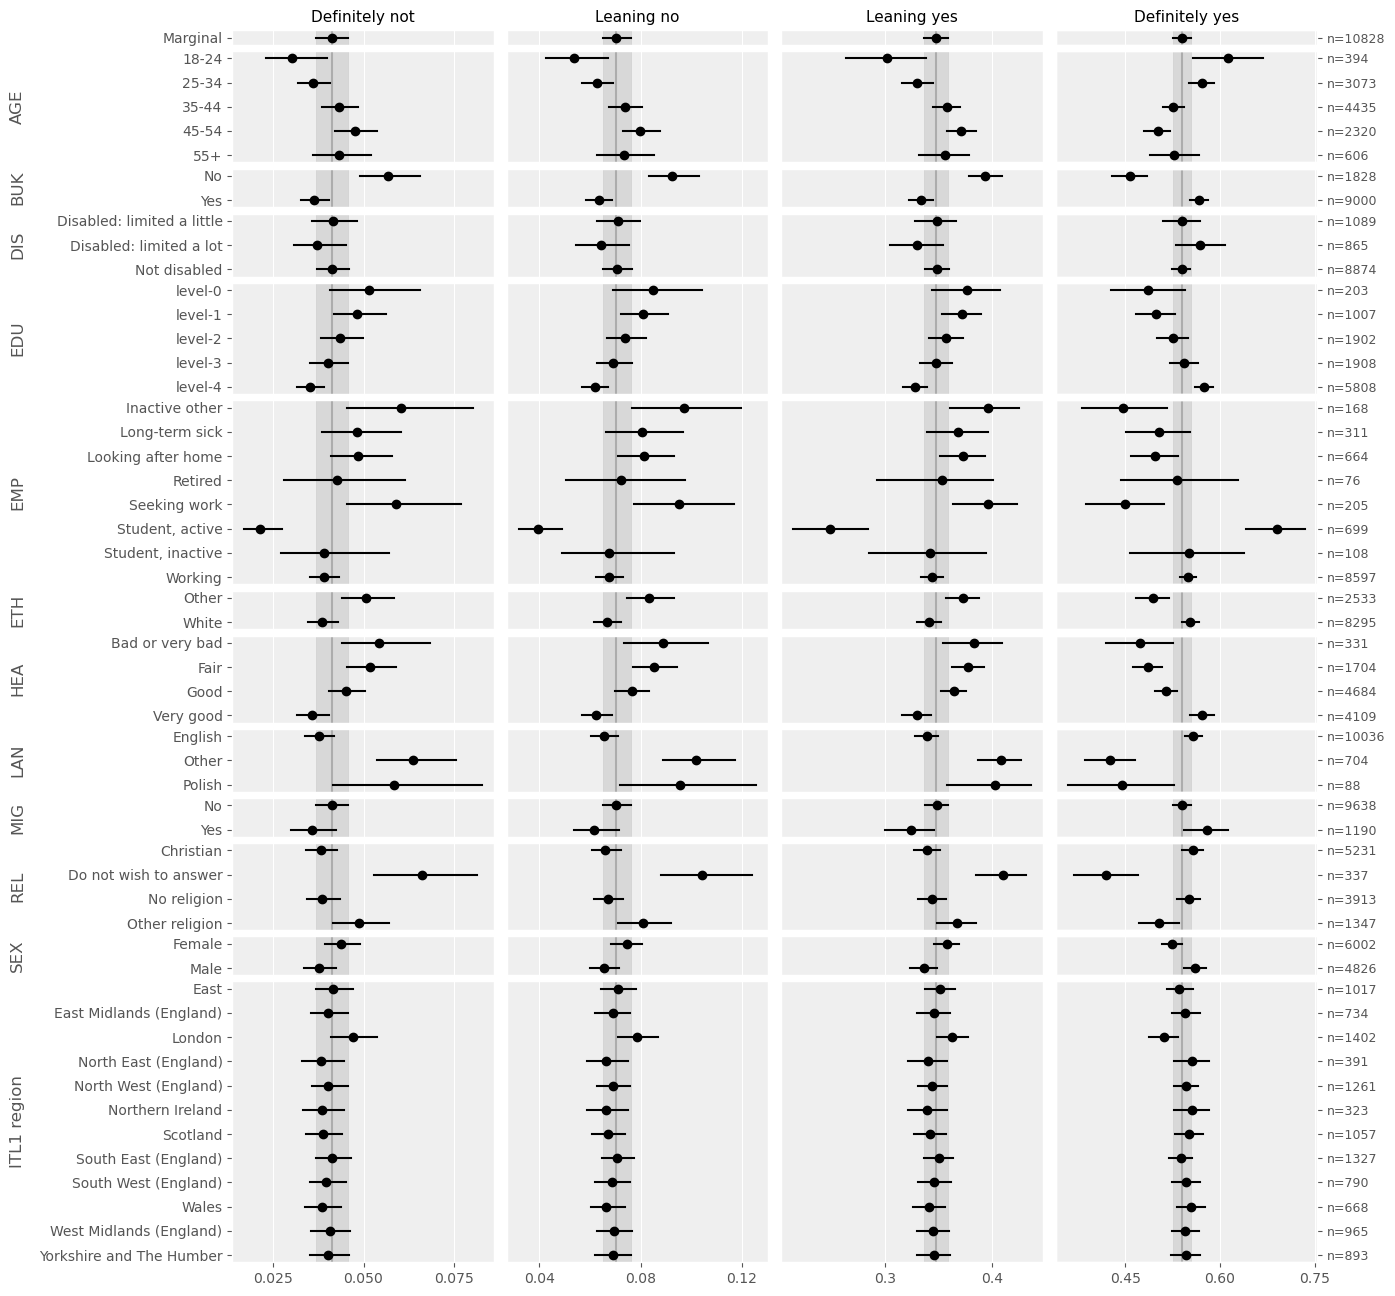

In [21]:
from matplotlib.ticker import MaxNLocator
from matplotlib.gridspec import GridSpec

plt.style.use('ggplot')
_var_list = ['AGE', 'SEX', 'EDU','REL', 'ETH', 'LAN', 'MIG', 'BUK', 'DIS', 'HEA', 'EMP'] #,'country'] # ,'EMP'


_var_list = ['Marginal'] + list(np.sort(_var_list)) + ['itl1']

add_n = True

_y_offset = 0.3
def _get_height(num_rows, y_offset):
    return (num_rows-1) + y_offset - (-y_offset)

# Calculate height ratios
height_ratios = [_get_height(df_post_strat_dict[var_post_strat].shape[0], y_offset=_y_offset) for var_post_strat in _var_list]

fig = plt.figure(figsize=(14, 16) ) # , constrained_layout = True)
gs = GridSpec(len(_var_list), 4, figure=fig, wspace=0.05, hspace=0.07, height_ratios=height_ratios)

axes = []
for i in range(len(_var_list)):
    row_axes = []
    for j in range(4):
        if i == 0:
            ax = fig.add_subplot(gs[i, j])
        else:
            ax = fig.add_subplot(gs[i, j], sharex=axes[0][j])
        row_axes.append(ax)
        ###
    axes.append(row_axes)

fig.align_labels()
titles = ['Definitely not', 'Leaning no', 'Leaning yes', 'Definitely yes']
for i, var_post_strat in enumerate( _var_list ): #, 'EMP'] ):
    num_rows = df_post_strat_dict[var_post_strat].shape[0]
    for j,var_name in enumerate(['p1','p2','p3','p4']):
        ax = axes[i][j]
        # Plot each ITL3 region
        for k, (index, row) in enumerate(df_post_strat_dict[var_post_strat].iterrows()):
            ax.plot([row[f'{var_name}_2.5percentile'], row[f'{var_name}_97.5percentile']], [num_rows - 1 - k, num_rows - 1 - k], color='black')  # Line from 2.5 to 97.5 percentile
            ax.plot(row[f'{var_name}_50percentile'], num_rows - 1 - k, 'o', color='black')  # Marker at 50 percentile

        ax.xaxis.set_major_locator(MaxNLocator(nbins=3))
        if j == 0:
            ax.set_yticks( range( num_rows ) )
            _ytick_labels =  list(df_post_strat_dict[var_post_strat].index)[::-1]
            if var_post_strat == 'DIS':
                _ytick_labels = [label.replace('\n', ' ')for label in _ytick_labels]
            ax.set_yticklabels( _ytick_labels) #, fontsize = 9) # , fontfamily='monospace' )
        else:
            ax.set_yticks( [] )
        ax.set_ylim( -_y_offset, (num_rows-1) + _y_offset )
        if i == 0:
            ax.set_title(titles[j], size = 11)

        if i < len(_var_list) - 1:
            ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)

        #######################
        # Get the 2.5, 50, and 97.5 percentiles
        percentile_2_5 = df_post_strat_dict['Marginal'][f'{var_name}_2.5percentile'].values[0]
        percentile_50 = df_post_strat_dict['Marginal'][f'{var_name}_50percentile'].values[0]
        percentile_97_5 = df_post_strat_dict['Marginal'][f'{var_name}_97.5percentile'].values[0]

        ax.axvline(percentile_50, zorder=0, color='grey', alpha=0.5)

        ax.fill_betweenx(
            y=[ax.get_ylim()[0], ax.get_ylim()[1]], 
            x1=percentile_2_5,
            x2=percentile_97_5,
            color='grey',
            alpha=0.2,  
            zorder=0
        )
        ########################
        ax.patch.set_facecolor( mcolors.to_rgba('gainsboro', alpha_soc_backgound) )
    if var_post_strat not in ['Marginal', 'itl1']:
        axes[i][0].set_ylabel(var_post_strat, labelpad=10)
    if var_post_strat in ['itl1']:
        axes[i][0].set_ylabel(f'ITL1 region', labelpad=10)
    axes[i][0].grid(axis='y', visible=False)

    if add_n:
        num_n = dict( survey_mrp[var_post_strat].value_counts() )
        num_n = {k : f'n={v}' for k,v in num_n.items()}
        ax2 = axes[i][-1].twinx()
        ax2.set_ylim(axes[i][0].get_ylim())
        ax2.set_yticks(axes[i][0].get_yticks())
        ax2.set_yticklabels([num_n[col] for col in list(df_post_strat_dict[var_post_strat].index)[::-1] ], fontsize = 9)
        ax2.grid(False) 

fig.savefig('./fig/uk/rsv_intent_uk_mrp_socio_dems_itl1_poststrat.jpg', dpi = 200, bbox_inches='tight')

plt.show()

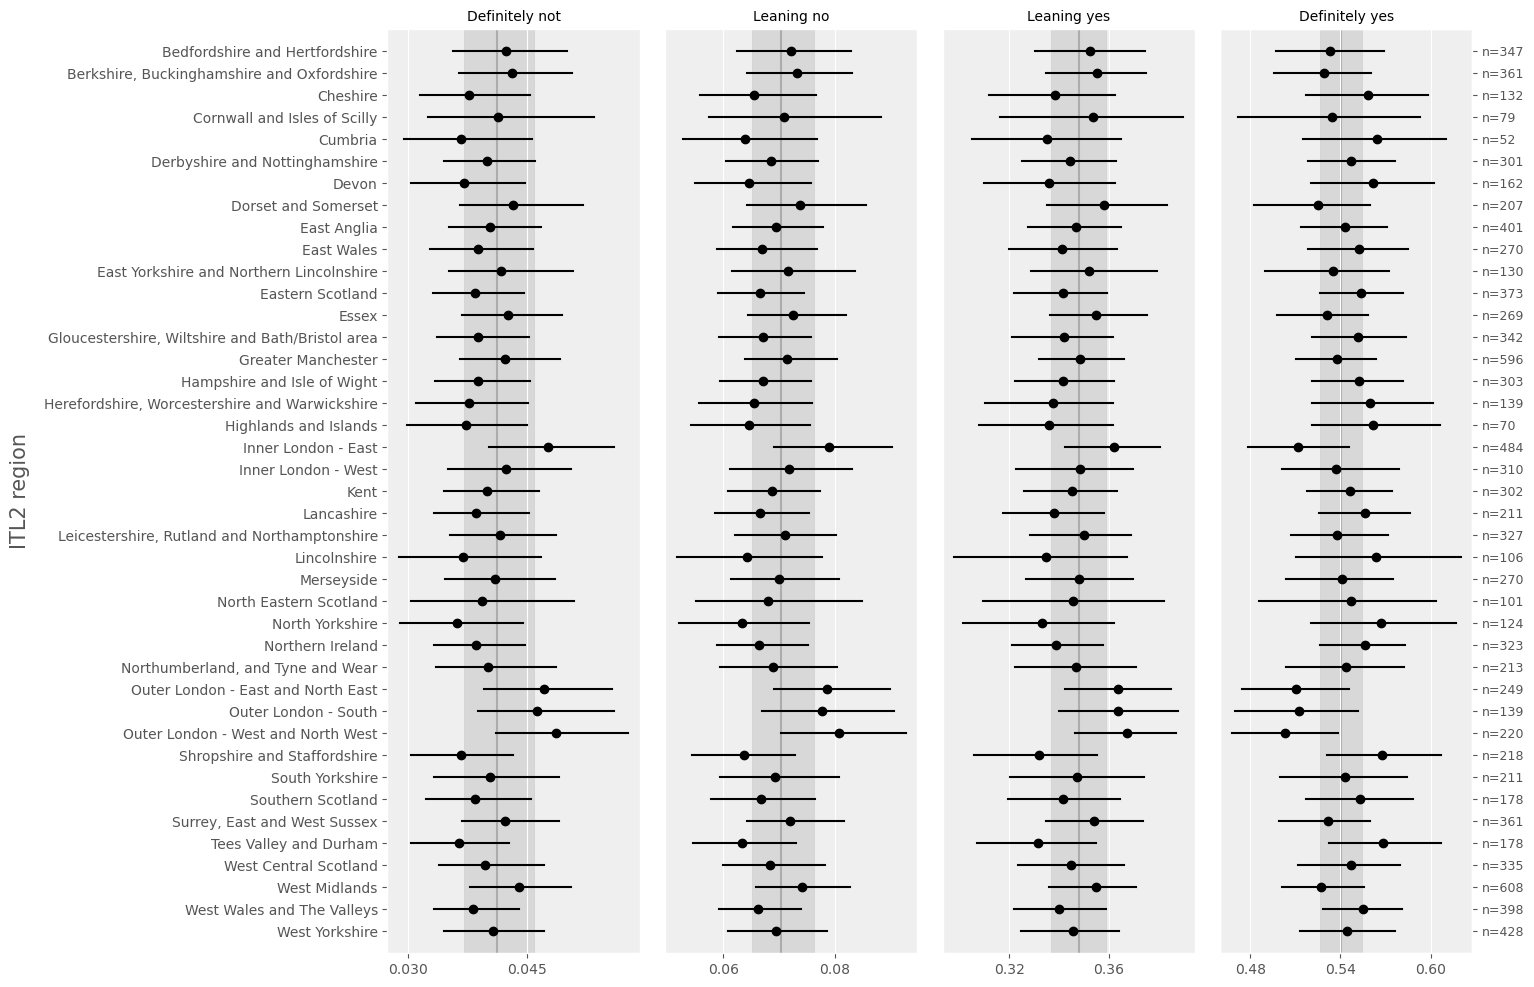

In [22]:
from matplotlib.ticker import MaxNLocator
from matplotlib.gridspec import GridSpec

plt.style.use('ggplot')

_var_list = ['itl2'] # ,'EMP'

add_n = True

_y_offset = 1.0
def _get_height(num_rows, y_offset):
    return (num_rows-1) + y_offset - (-y_offset)

# Calculate height ratios
height_ratios = [_get_height(df_post_strat_dict[var_post_strat].shape[0], y_offset=_y_offset) for var_post_strat in _var_list]

fig = plt.figure(figsize=(14, 12) ) # , constrained_layout = True)
gs = GridSpec(len(_var_list), 4, figure=fig, wspace=0.1, hspace=0.5, height_ratios=height_ratios)

axes = []
for i in range(len(_var_list)):
    row_axes = []
    for j in range(4):
        ax = fig.add_subplot(gs[i, j])
        row_axes.append(ax)
    axes.append(row_axes)

fig.align_labels()
titles = ['Definitely not', 'Leaning no', 'Leaning yes', 'Definitely yes']

for i, var_post_strat in enumerate( _var_list ): #, 'EMP'] ):
    num_rows = df_post_strat_dict[var_post_strat].shape[0]
    for j,var_name in enumerate(['p1','p2','p3','p4']):
        ax = axes[i][j]
        # Plot each ITL3 region
        for k, (index, row) in enumerate(df_post_strat_dict[var_post_strat].iterrows()):
            ax.plot([row[f'{var_name}_2.5percentile'], row[f'{var_name}_97.5percentile']], [num_rows - 1 - k, num_rows - 1 - k], color='black')  # Line from 2.5 to 97.5 percentile
            ax.plot(row[f'{var_name}_50percentile'], num_rows - 1 - k, 'o', color='black')  # Marker at 50 percentile
        
        # Set y-ticks and labels
        ax.xaxis.set_major_locator(MaxNLocator(nbins=3))
        if j == 0:
            ax.set_yticks( range( num_rows ) )
            ax.set_yticklabels( list(df_post_strat_dict[var_post_strat].index)[::-1]) #, fontsize = 9) # , fontfamily='monospace' )
        else:
            ax.set_yticks( [] )
        ax.set_ylim( -_y_offset, (num_rows-1) + _y_offset )
        if i == 0:
            ax.set_title(titles[j], size = 10)
            ax.grid(axis='y', visible=False)
        #######################
        # Get the 2.5, 50, and 97.5 percentiles
        percentile_2_5 = df_post_strat_dict['Marginal'][f'{var_name}_2.5percentile'].values[0]
        percentile_50 = df_post_strat_dict['Marginal'][f'{var_name}_50percentile'].values[0]
        percentile_97_5 = df_post_strat_dict['Marginal'][f'{var_name}_97.5percentile'].values[0]

        ax.axvline(percentile_50, zorder=0, color='grey', alpha=0.5)
        
        # Fill between the 2.5 and 97.5 percentiles
        ax.fill_betweenx(
            y=[ax.get_ylim()[0], ax.get_ylim()[1]],  
            x1=percentile_2_5,
            x2=percentile_97_5,
            color='grey',
            alpha=0.2,  
            zorder=0
        )
        ########################
        ax.patch.set_facecolor( mcolors.to_rgba('gainsboro', alpha_soc_backgound) )
    axes[i][0].set_ylabel('ITL2 region', labelpad=10, size = 15)
    if add_n:
        if var_post_strat != 'country':
            num_n = dict( survey_mrp[var_post_strat].value_counts() )
            num_n = {k : f'n={v}' for k,v in num_n.items()}
            ax2 = axes[i][-1].twinx()
            ax2.set_ylim(axes[i][0].get_ylim())
            ax2.set_yticks(axes[i][0].get_yticks())
            ax2.set_yticklabels([num_n[col] for col in list(df_post_strat_dict[var_post_strat].index)[::-1] ], fontsize = 9)
            ax2.grid(False) 


fig.savefig('./fig/uk/rsv_intent_uk_mrp_itl2_poststrat.jpg', dpi = 200, bbox_inches='tight')
plt.show()

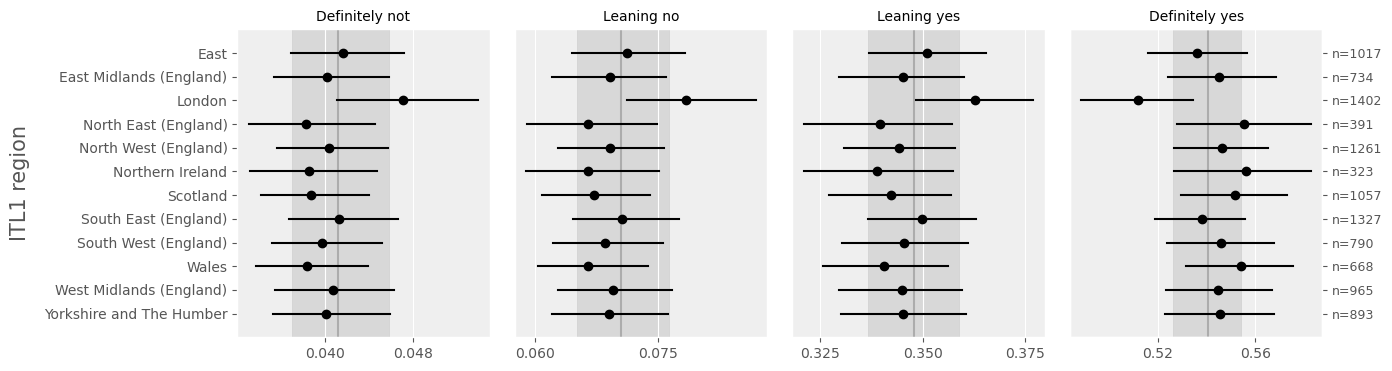

In [23]:
from matplotlib.ticker import MaxNLocator
from matplotlib.gridspec import GridSpec

plt.style.use('ggplot')

_var_list = ['itl1'] # ,'EMP'

add_n = True

_y_offset = 1.0
def _get_height(num_rows, y_offset):
    return (num_rows-1) + y_offset - (-y_offset)

# Calculate height ratios
height_ratios = [_get_height(df_post_strat_dict[var_post_strat].shape[0], y_offset=_y_offset) for var_post_strat in _var_list]

fig = plt.figure(figsize=(14, 4) ) # , constrained_layout = True)
gs = GridSpec(len(_var_list), 4, figure=fig, wspace=0.1, hspace=0.5, height_ratios=height_ratios)

axes = []
for i in range(len(_var_list)):
    row_axes = []
    for j in range(4):
        ax = fig.add_subplot(gs[i, j])
        row_axes.append(ax)
    axes.append(row_axes)

fig.align_labels()
titles = ['Definitely not', 'Leaning no', 'Leaning yes', 'Definitely yes']

for i, var_post_strat in enumerate( _var_list ): #, 'EMP'] ):
    num_rows = df_post_strat_dict[var_post_strat].shape[0]
    for j,var_name in enumerate(['p1','p2','p3','p4']):
        ax = axes[i][j]
        # Plot each ITL3 region
        for k, (index, row) in enumerate(df_post_strat_dict[var_post_strat].iterrows()):
            ax.plot([row[f'{var_name}_2.5percentile'], row[f'{var_name}_97.5percentile']], [num_rows - 1 - k, num_rows - 1 - k], color='black')  # Line from 2.5 to 97.5 percentile
            ax.plot(row[f'{var_name}_50percentile'], num_rows - 1 - k, 'o', color='black')  # Marker at 50 percentile
        
        # Set y-ticks and labels
        ax.xaxis.set_major_locator(MaxNLocator(nbins=3))
        if j == 0:
            ax.set_yticks( range( num_rows ) )
            ax.set_yticklabels( list(df_post_strat_dict[var_post_strat].index)[::-1]) #, fontsize = 9) # , fontfamily='monospace' )
        else:
            ax.set_yticks( [] )
        ax.set_ylim( -_y_offset, (num_rows-1) + _y_offset )
        if i == 0:
            ax.set_title(titles[j], size = 10)
            ax.grid(axis='y', visible=False)
        #######################
        # Get the 2.5, 50, and 97.5 percentiles
        percentile_2_5 = df_post_strat_dict['Marginal'][f'{var_name}_2.5percentile'].values[0]
        percentile_50 = df_post_strat_dict['Marginal'][f'{var_name}_50percentile'].values[0]
        percentile_97_5 = df_post_strat_dict['Marginal'][f'{var_name}_97.5percentile'].values[0]
        
        # Plot the central line for the median
        ax.axvline(percentile_50, zorder=0, color='grey', alpha=0.5)
        
        # Fill between the 2.5 and 97.5 percentiles
        ax.fill_betweenx(
            y=[ax.get_ylim()[0], ax.get_ylim()[1]], 
            x1=percentile_2_5,
            x2=percentile_97_5,
            color='grey',
            alpha=0.2, 
            zorder=0
        )
        ########################
        ax.patch.set_facecolor( mcolors.to_rgba('gainsboro', alpha_soc_backgound) )
    axes[i][0].set_ylabel('ITL1 region', labelpad=10, size = 15)
    if add_n:
        if var_post_strat != 'country':
            num_n = dict( survey_mrp[var_post_strat].value_counts() )
            num_n = {k : f'n={v}' for k,v in num_n.items()}
            ax2 = axes[i][-1].twinx()
            ax2.set_ylim(axes[i][0].get_ylim())
            ax2.set_yticks(axes[i][0].get_yticks())
            ax2.set_yticklabels([num_n[col] for col in list(df_post_strat_dict[var_post_strat].index)[::-1] ], fontsize = 9)
            ax2.grid(False) 


fig.savefig('./fig/uk/rsv_intent_uk_mrp_itl1_poststrat.jpg', dpi = 200, bbox_inches='tight')
plt.show()

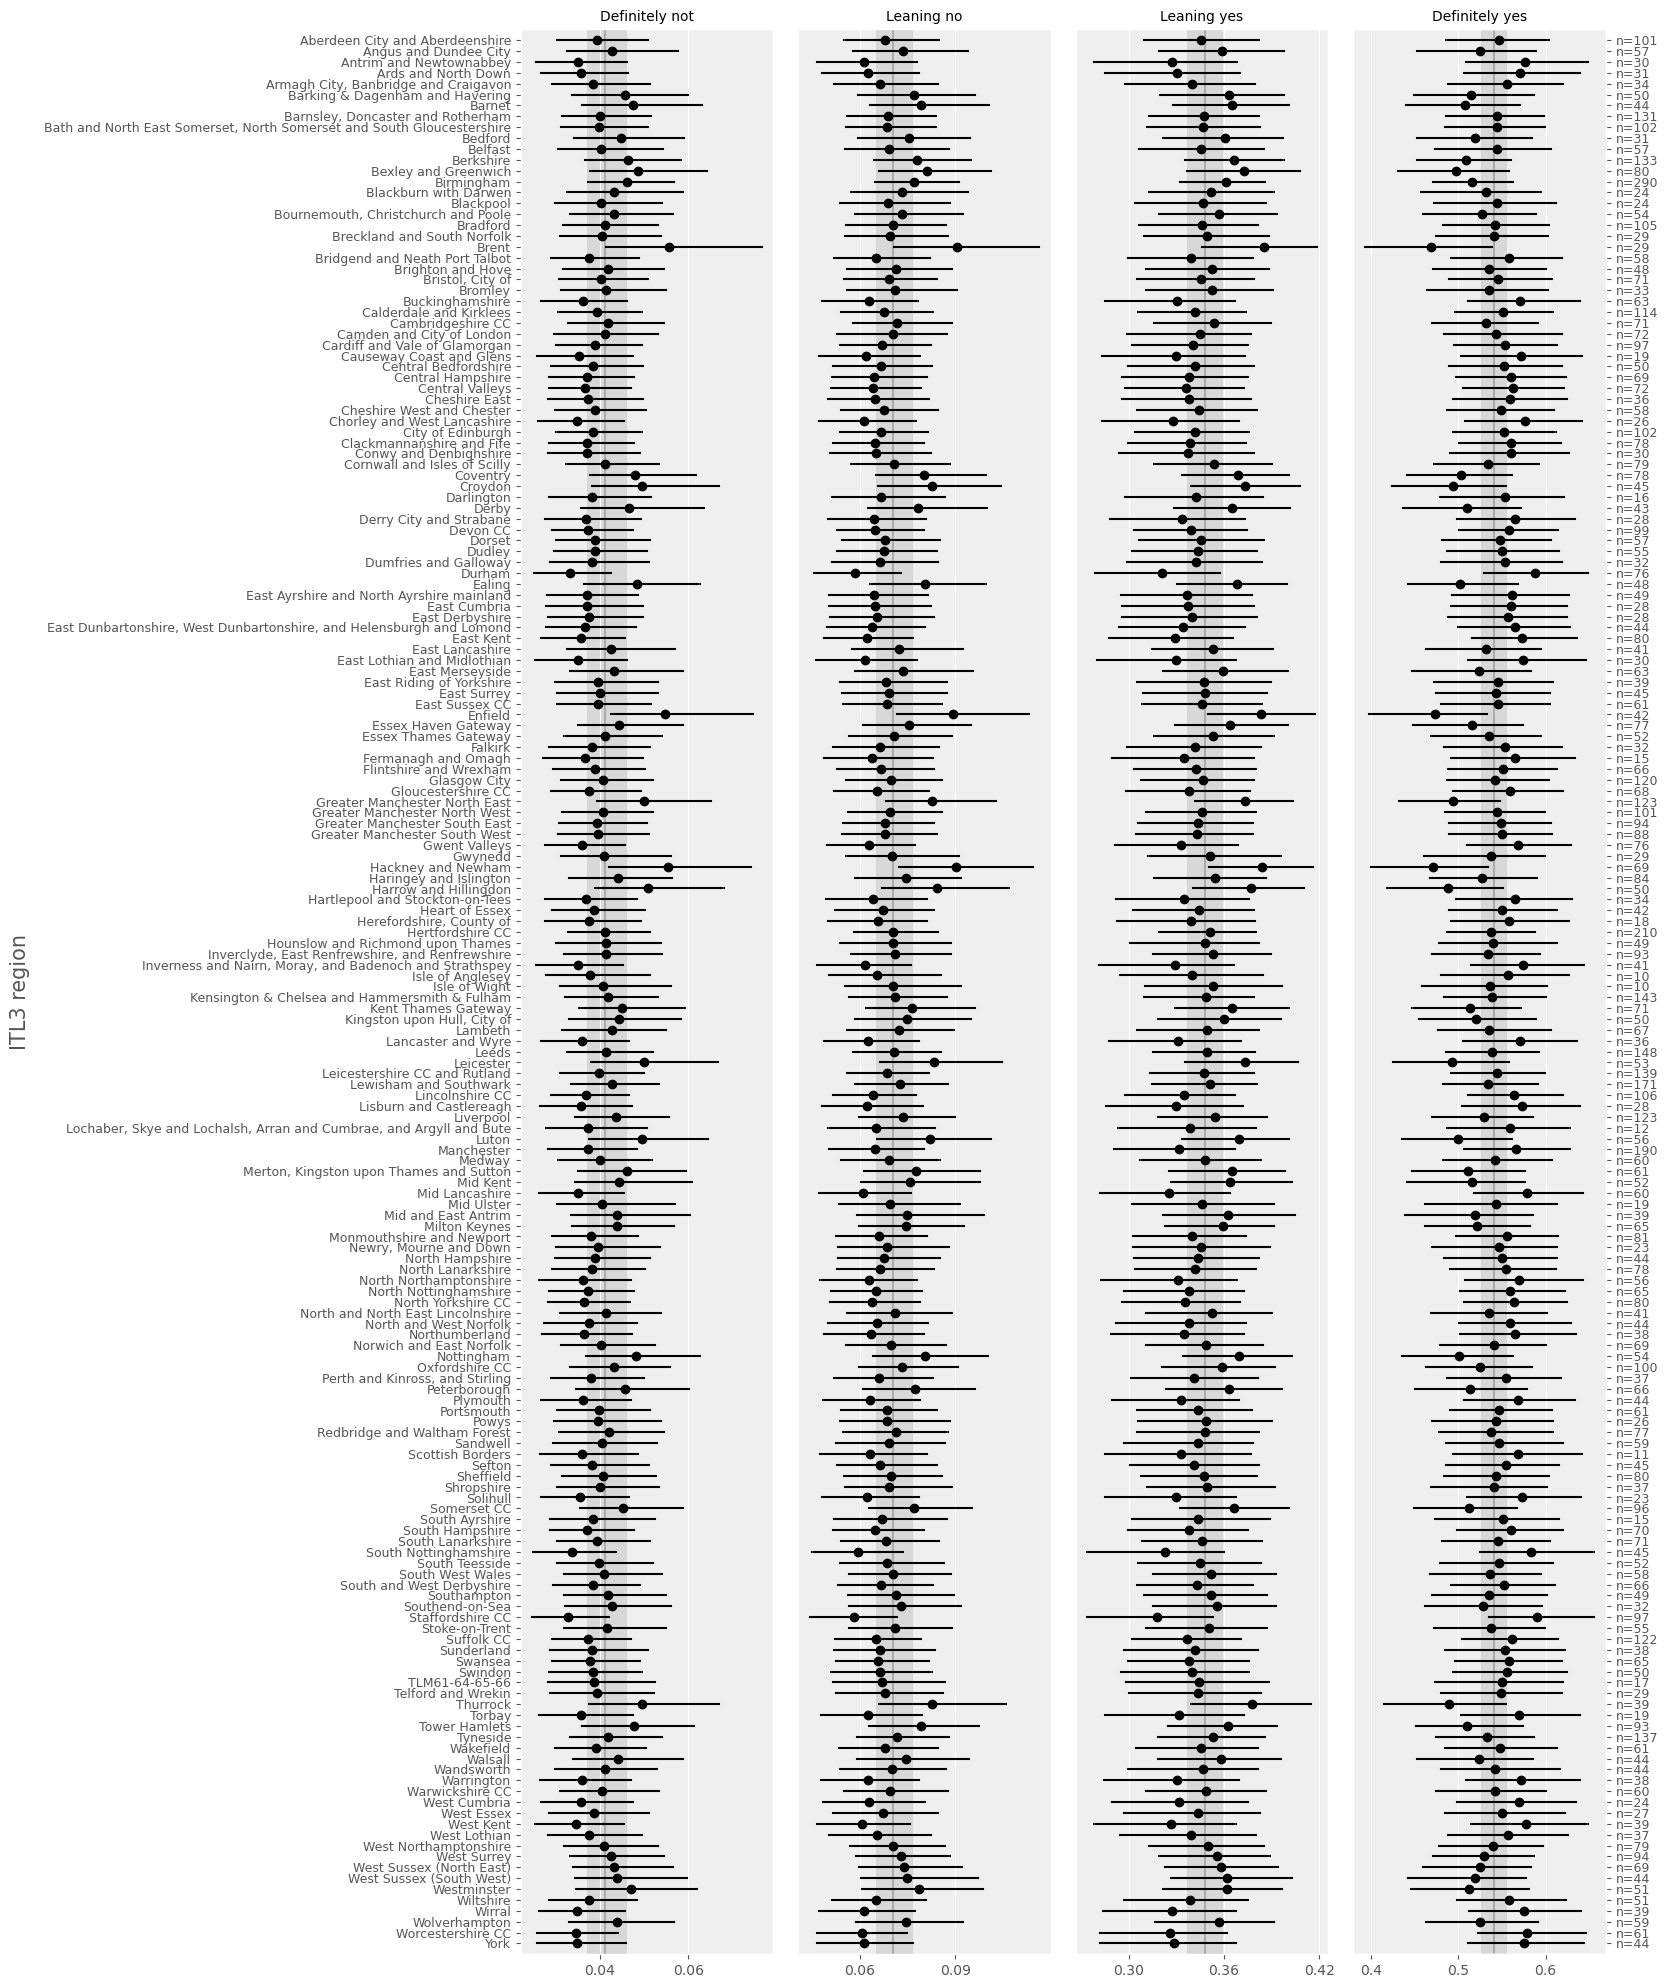

In [24]:
from matplotlib.ticker import MaxNLocator
from matplotlib.gridspec import GridSpec

_var_list = ['itl3'] # ,'EMP'

add_n = True

_y_offset = 1.0
def _get_height(num_rows, y_offset):
    return (num_rows-1) + y_offset - (-y_offset)

# Calculate height ratios
height_ratios = [_get_height(df_post_strat_dict[var_post_strat].shape[0], y_offset=_y_offset) for var_post_strat in _var_list]

# Create a GridSpec with consistent spacing and height ratios
fig = plt.figure(figsize=(14, 25) ) # , constrained_layout = True)
gs = GridSpec(len(_var_list), 4, figure=fig, wspace=0.1, hspace=0.5, height_ratios=height_ratios)

axes = []
for i in range(len(_var_list)):
    row_axes = []
    for j in range(4):
        ax = fig.add_subplot(gs[i, j])
        row_axes.append(ax)
    axes.append(row_axes)

fig.align_labels()
titles = ['Definitely not', 'Leaning no', 'Leaning yes', 'Definitely yes']

for i, var_post_strat in enumerate( _var_list ): #, 'EMP'] ):
    num_rows = df_post_strat_dict[var_post_strat].shape[0]
    for j,var_name in enumerate(['p1','p2','p3','p4']):
        ax = axes[i][j]
        # Plot each ITL3 region
        for k, (index, row) in enumerate(df_post_strat_dict[var_post_strat].iterrows()):
            ax.plot([row[f'{var_name}_2.5percentile'], row[f'{var_name}_97.5percentile']], [num_rows - 1 - k, num_rows - 1 - k], color='black')  # Line from 2.5 to 97.5 percentile
            ax.plot(row[f'{var_name}_50percentile'], num_rows - 1 - k, 'o', color='black')  # Marker at 50 percentile
        
        # Set y-ticks and labels
        ax.xaxis.set_major_locator(MaxNLocator(nbins=3))
        if j == 0:
            ax.set_yticks( range( num_rows ) )
            ax.set_yticklabels( list(df_post_strat_dict[var_post_strat].index)[::-1], fontsize = 9) # , fontfamily='monospace' )
        else:
            ax.set_yticks( [] )
        ax.set_ylim( -_y_offset, (num_rows-1) + _y_offset )
        if i == 0:
            ax.set_title(titles[j], size = 10)
            ax.grid(axis='y', visible=False)
        #######################
        # Get the 2.5, 50, and 97.5 percentiles
        percentile_2_5 = df_post_strat_dict['Marginal'][f'{var_name}_2.5percentile'].values[0]
        percentile_50 = df_post_strat_dict['Marginal'][f'{var_name}_50percentile'].values[0]
        percentile_97_5 = df_post_strat_dict['Marginal'][f'{var_name}_97.5percentile'].values[0]

        ax.axvline(percentile_50, zorder=0, color='grey', alpha=0.5)
        
        # Fill between the 2.5 and 97.5 percentiles
        ax.fill_betweenx(
            y=[ax.get_ylim()[0], ax.get_ylim()[1]],  
            x1=percentile_2_5,
            x2=percentile_97_5,
            color='grey',
            alpha=0.2, 
            zorder=0
        )
        ########################
        ax.patch.set_facecolor( mcolors.to_rgba('gainsboro', alpha_soc_backgound) )
    axes[i][0].set_ylabel('ITL3 region', labelpad=10, size = 15)
    if add_n:
        if var_post_strat != 'country':
            num_n = dict( survey_mrp[var_post_strat].value_counts() )
            num_n = {k : f'n={v}' for k,v in num_n.items()}
            ax2 = axes[i][-1].twinx()
            ax2.set_ylim(axes[i][0].get_ylim())
            ax2.set_yticks(axes[i][0].get_yticks())
            ax2.set_yticklabels([num_n[col] for col in list(df_post_strat_dict[var_post_strat].index)[::-1] ], fontsize = 9)
            ax2.grid(False) 


fig.savefig('./fig/uk/rsv_intent_uk_mrp_itl3_poststrat.jpg', dpi = 200, bbox_inches='tight')
plt.show()